# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [52]:
!pip install phik -q

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from phik import phik_matrix

In [54]:
db_config = {
    'user': 'praktikum_student',
    'password': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'dbname': 'data-analyst-afisha'
}

connection_string = (
    f"postgresql://{db_config['user']}:{db_config['password']}"
    f"@{db_config['host']}:{db_config['port']}/{db_config['dbname']}"
)

engine = create_engine(connection_string)

In [55]:
query = """
WITH set_config_precode AS (
    SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    DATE_PART(
        'day',
        p.created_dt_msk - LAG(p.created_dt_msk) OVER (
            PARTITION BY p.user_id
            ORDER BY p.created_dt_msk
        )
    )::int AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
INNER JOIN afisha.events AS e
    ON p.event_id = e.event_id
INNER JOIN afisha.city AS c
    ON e.city_id = c.city_id
INNER JOIN afisha.regions AS r
    ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id
"""

In [56]:
df = pd.read_sql_query(text(query), engine)
print(df.shape)
df.head()

(290611, 14)


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [57]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [58]:
df.isna().sum().sort_values(ascending=False)

days_since_prev          21933
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
dtype: int64

In [59]:
df.describe()

,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,625.584360,2.754311,3.222381,438019.834992
std,2.497551e+06,1227.693064,1.170620,11.350509,147423.078841
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000


Данные загрузились корректно: в выборке 290 611 заказов, а значит объёма достаточно, чтобы дальше изучать поведение пользователей и искать различия между сегментами.

С точки зрения полноты выгрузка выглядит хорошо. Пропуски есть только в `days_since_prev` у части пользователей был всего один заказ, поэтому посчитать интервал до предыдущей покупки для них невозможно. В остальных столбцах пропусков нет, значит ключевая информация о заказах, устройствах, мероприятиях и географии сохранилась полностью.

В столбце с выручкой встречаются отрицательные значения а в количестве билетов есть очень крупные заказы — такие наблюдения нужно отдельно проверить, потому что они могут искажать картину. Кроме того выручка хранится в разных валютах, поэтому следующим шагом её нужно привести к рублям, чтобы сравнения были корректными.

В целом выгрузка выглядит качественной и подходит для дальнейшей работы.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [60]:
tenge_df = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

df['order_dt'] = pd.to_datetime(df['order_dt'])
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

df = df.merge(
    tenge_df[['data', 'curs', 'nominal']],
    left_on='order_dt',
    right_on='data',
    how='left'
)

df['revenue_rub'] = df['revenue'].astype('float32')

mask = df['currency_code'] == 'kzt'
df.loc[mask, 'revenue_rub'] = (
    df.loc[mask, 'revenue'].astype('float32')
    / df.loc[mask, 'nominal'].astype('float32')
    * df.loc[mask, 'curs'].astype('float32')
)

df['revenue_rub'] = df['revenue_rub'].astype('float32')
df = df.drop(columns=['data', 'curs', 'nominal'])

df[['currency_code', 'revenue', 'revenue_rub']].head()


,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.939941
1,rub,289.45,289.450012
2,rub,1258.57,1258.569946
3,rub,8.49,8.490000
4,rub,1390.41,1390.410034


In [61]:
df.groupby('currency_code')[['revenue', 'revenue_rub']].agg(['count', 'mean']).round(2)


revenue          revenue_rub            
                count     mean       count        mean
currency_code                                         
kzt              5069  4995.21        5069  981.330017
rub            285542   548.01      285542  548.010010

In [62]:
df['revenue_rub'].describe(percentiles=[0.95, 0.99])


count    290611.000000
mean        555.571838
std         875.498169
min         -90.760002
50%         351.140015
95%        1630.650024
99%        2628.421631
max       81174.539062
Name: revenue_rub, dtype: float64

Пропуски сохранились только в `days_since_prev`, что ожидаемо для пользователей с одним заказом. Остальные столбцы заполнены корректно, поэтому структура данных в целом выглядит надёжной для дальнейшего анализа.

Типы данных были приведены к более удобному и компактному виду: даты переведены в формат datetime, числовые столбцы — в 32-битные типы, а категориальные признаки — в category. Это снижает расход памяти и упрощает дальнейшую обработку.

Дополнительно были проверены числовые показатели и категориальные значения. В выручке наблюдаются выбросы, поэтому для дальнейшего анализа данные были отфильтрованы по 99-му перцентилю `revenue_rub`. Это позволяет уменьшить влияние аномально крупных заказов и сделать последующие выводы более устойчивыми.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [63]:
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])

df['revenue'] = df['revenue'].astype('float32')
df['revenue_rub'] = df['revenue_rub'].astype('float32')
df['tickets_count'] = df['tickets_count'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')
df['days_since_prev'] = df['days_since_prev'].astype('float32')

for col in ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main', 'region_name', 'city_name']:
    df[col] = df[col].astype('category')

df.isna().sum().sort_values(ascending=False)


days_since_prev          21933
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

In [64]:
display(df[['revenue_rub', 'tickets_count']].describe(percentiles=[0.95, 0.99]))

for col in ['device_type_canonical', 'currency_code', 'event_type_main']:
    display(df[col].value_counts(dropna=False))

display(df['service_name'].value_counts(dropna=False).head(10))
display(df['region_name'].value_counts(dropna=False).head(10))
display(df['city_name'].value_counts(dropna=False).head(10))


,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,555.571838,2.754311
std,875.498169,1.170620
min,-90.760002,1.000000
50%,351.140015,3.000000
95%,1630.650024,5.000000
99%,2628.421631,6.000000
max,81174.539062,57.000000


mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

rub    285542
kzt      5069
Name: currency_code, dtype: int64

концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Лучшие билеты         17774
Весь в билетах        16849
Прачечная             10273
Край билетов           6207
Тебе билет!            5228
Name: service_name, dtype: int64

Каменевский регион         91058
Североярская область       44049
Широковская область        16457
Медовская область          13901
Озернинский край           10476
Светополянский округ        7607
Малиновоярский округ        6618
Речиновская область         6293
Солнечноземская область     6288
Яблоневская область         6181
Name: region_name, dtype: int64

Глиногорск      89446
Озёрск          43910
Радужсвет       13711
Радужнополье     8741
Верховино        6579
Дальнесветск     6293
Глинополье       6196
Светополье       5993
Глиноград        5934
Лесоярич         5831
Name: city_name, dtype: int64

In [65]:
rows_before = len(df)
revenue_99 = df['revenue_rub'].quantile(0.99)

df = df[df['revenue_rub'] <= revenue_99].copy()

rows_after = len(df)

print(revenue_99)
print(rows_before - rows_after)
print(round((rows_before - rows_after) / rows_before * 100, 2))


2628.421630859375
2825
0.97


На этапе предобработки я проверила пропуски, типы данных, категориальные значения и числовые показатели. Пропуски сохранились только в `days_since_prev`, что ожидаемо для пользователей с одним заказом. В остальных столбцах критичных проблем не обнаружено.

Типы данных были приведены к более компактному виду: числовые столбцы переведены в 32-битные типы, а категориальные признаки — в `category`. Это позволяет экономнее расходовать память и при этом не усложняет код.

Дополнительно я проверила распределение выручки в рублях и количества билетов. В столбце `revenue_rub` наблюдаются выбросы, поэтому для дальнейшего анализа данные были отфильтрованы по 99-му перцентилю. В результате было удалено менее 1% строк, поэтому структура выборки практически не изменилась, а влияние аномально крупных заказов стало ниже.


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [66]:
df = df.sort_values(['user_id', 'order_ts']).copy()

first_orders = (
    df.groupby('user_id')
    .first()
    .reset_index()[[
        'user_id',
        'order_dt',
        'device_type_canonical',
        'region_name',
        'service_name',
        'event_type_main'
    ]]
    .rename(columns={
        'order_dt': 'first_order_dt',
        'device_type_canonical': 'first_device',
        'region_name': 'first_region',
        'service_name': 'first_service',
        'event_type_main': 'first_event_type'
    })
)

last_orders = (
    df.groupby('user_id')['order_dt']
    .max()
    .reset_index()
    .rename(columns={'order_dt': 'last_order_dt'})
)

In [67]:
profiles = (
    df.groupby('user_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        avg_revenue_rub=('revenue_rub', 'mean'),
        avg_tickets_count=('tickets_count', 'mean'),
        avg_days_between=('days_since_prev', 'mean')
    )
    .reset_index()
)

profiles = profiles.merge(first_orders, on='user_id', how='left')
profiles = profiles.merge(last_orders, on='user_id', how='left')

In [68]:
profiles['avg_revenue_rub'] = profiles['avg_revenue_rub'].astype('float32')
profiles['avg_tickets_count'] = profiles['avg_tickets_count'].astype('float32')
profiles['avg_days_between'] = profiles['avg_days_between'].astype('float32')
profiles['total_orders'] = profiles['total_orders'].astype('int32')

profiles['is_two'] = (profiles['total_orders'] >= 2).astype('int8')
profiles['is_five'] = (profiles['total_orders'] >= 5).astype('int8')

profiles.head()

,user_id,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,first_order_dt,first_device,first_region,first_service,first_event_type,last_order_dt,is_two,is_five
0,0002849b70a3ce2,1,1521.939941,4.000000,NaN,2024-08-20,mobile,Каменевский регион,Край билетов,театр,2024-08-20,0,0
1,0005ca5e93f2cf4,2,774.010010,3.000000,75.0,2024-07-23,mobile,Каменевский регион,Мой билет,выставки,2024-10-06,1,0
2,000898990054619,3,767.213318,2.666667,51.0,2024-07-13,mobile,Североярская область,Лови билет!,другое,2024-10-23,1,0
3,00096d1f542ab2b,1,917.830017,4.000000,NaN,2024-08-15,desktop,Каменевский регион,Край билетов,театр,2024-08-15,0,0
4,000a55a418c128c,2,61.309998,1.500000,16.0,2024-09-29,mobile,Поленовский край,Лучшие билеты,театр,2024-10-15,1,0


На этом этапе был построен профиль пользователя, который объединяет как характеристики первого заказа, так и агрегированные показатели поведения. Для каждого пользователя были определены дата первого и последнего заказа, устройство, регион, билетный оператор и тип первого мероприятия, а также рассчитаны общее число заказов, средняя выручка с заказа в рублях, среднее количество билетов и средний интервал между покупками.

Дополнительно были созданы бинарные признаки `is_two` и `is_five`, которые показывают, совершал ли пользователь повторные заказы. Такой профиль удобен для дальнейшего анализа, потому что позволяет изучать не отдельные покупки, а поведение пользователя в целом.

Числовые столбцы были приведены к компактным типам `float32`, `int32` и `int8`, что снижает расход памяти без усложнения решения. Полученный датафрейм `profiles` можно использовать как основу для последующего исследовательского анализа факторов возврата пользователей.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [69]:
users_total = profiles['user_id'].nunique()
avg_order_revenue = profiles['avg_revenue_rub'].mean()
share_two = profiles['is_two'].mean()
share_five = profiles['is_five'].mean()

print(users_total)
print(avg_order_revenue)
print(share_two)
print(share_five)

21854
544.3981
0.6170952686007138
0.2900613160062231


In [70]:
display(profiles[['total_orders', 'avg_tickets_count', 'avg_days_between']].describe(percentiles=[0.95, 0.99]))

orders_99 = profiles['total_orders'].quantile(0.99)
tickets_99 = profiles['avg_tickets_count'].quantile(0.99)

print(orders_99)
print(tickets_99)

,total_orders,avg_tickets_count,avg_days_between
count,21854.000000,21854.000000,13515.000000
mean,13.168573,2.743129,15.847322
std,121.674800,0.913080,22.298574
min,1.000000,1.000000,0.000000
50%,2.000000,2.750000,8.000000
95%,31.350000,4.000000,61.500000
99%,152.000000,5.000000,112.000000
max,10181.000000,11.000000,148.000000


152.0
5.0


In [71]:
rows_before = len(profiles)

profiles = profiles[
    (profiles['total_orders'] <= orders_99) &
    (profiles['avg_tickets_count'] <= tickets_99)
].copy()

rows_after = len(profiles)

print(rows_before - rows_after)
print(round((rows_before - rows_after) / rows_before * 100, 2))

display(profiles[['total_orders', 'avg_tickets_count', 'avg_days_between']].describe(percentiles=[0.95, 0.99]))

410
1.88


,total_orders,avg_tickets_count,avg_days_between
count,21444.000000,21444.000000,13235.000000
mean,6.543928,2.713848,16.142645
std,14.380600,0.864849,22.403837
min,1.000000,1.000000,0.000000
50%,2.000000,2.750000,8.400000
95%,26.000000,4.000000,62.000000
99%,80.000000,5.000000,113.000000
max,152.000000,5.000000,148.000000


Профили пользователей дают достаточно полную картину для дальнейшего анализа: в датасете можно оценить и масштаб выборки, и долю возвращающихся пользователей, и типичное поведение по числу заказов, количеству билетов и интервалам между покупками.

Предварительный осмотр показывает, что основная масса пользователей ведёт себя достаточно предсказуемо, но в данных могут встречаться отдельные аномально крупные значения по числу заказов и среднему количеству билетов. Такие наблюдения способны искажать общую картину, поэтому для большей устойчивости анализа профили были дополнительно отфильтрованы по 99-му перцентилю.

После фильтрации в выборке остаётся почти весь объём данных, а влияние редких экстремальных наблюдений снижается. Это делает дальнейшие выводы о возвратности пользователей более надёжными и лучше отражающими поведение основной части аудитории.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [72]:
df = df.sort_values(['user_id', 'order_ts']).copy()

first_orders = (
    df.groupby('user_id')
    .first()
    .reset_index()[[
        'user_id', 'order_dt', 'device_type_canonical',
        'region_name', 'service_name', 'event_type_main'
    ]]
    .rename(columns={
        'order_dt': 'first_order_dt',
        'device_type_canonical': 'first_device',
        'region_name': 'first_region',
        'service_name': 'first_service',
        'event_type_main': 'first_event_type'
    })
)

last_orders = (
    df.groupby('user_id')['order_dt']
    .max()
    .reset_index()
    .rename(columns={'order_dt': 'last_order_dt'})
)

In [73]:
profiles = (
    df.groupby('user_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        avg_revenue_rub=('revenue_rub', 'mean'),
        avg_tickets_count=('tickets_count', 'mean'),
        avg_days_between=('days_since_prev', 'mean')
    )
    .reset_index()
)

profiles = profiles.merge(first_orders, on='user_id', how='left')
profiles = profiles.merge(last_orders, on='user_id', how='left')

profiles['avg_revenue_rub'] = profiles['avg_revenue_rub'].astype('float32')
profiles['avg_tickets_count'] = profiles['avg_tickets_count'].astype('float32')
profiles['avg_days_between'] = profiles['avg_days_between'].astype('float32')
profiles['total_orders'] = profiles['total_orders'].astype('int32')

profiles['is_two'] = (profiles['total_orders'] >= 2).astype('int8')
profiles['is_five'] = (profiles['total_orders'] >= 5).astype('int8')

profiles.head()

,user_id,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,first_order_dt,first_device,first_region,first_service,first_event_type,last_order_dt,is_two,is_five
0,0002849b70a3ce2,1,1521.939941,4.000000,NaN,2024-08-20,mobile,Каменевский регион,Край билетов,театр,2024-08-20,0,0
1,0005ca5e93f2cf4,2,774.010010,3.000000,75.0,2024-07-23,mobile,Каменевский регион,Мой билет,выставки,2024-10-06,1,0
2,000898990054619,3,767.213318,2.666667,51.0,2024-07-13,mobile,Североярская область,Лови билет!,другое,2024-10-23,1,0
3,00096d1f542ab2b,1,917.830017,4.000000,NaN,2024-08-15,desktop,Каменевский регион,Край билетов,театр,2024-08-15,0,0
4,000a55a418c128c,2,61.309998,1.500000,16.0,2024-09-29,mobile,Поленовский край,Лучшие билеты,театр,2024-10-15,1,0


In [74]:
event_segments = (
    profiles.groupby('first_event_type')
    .agg(users=('user_id', 'nunique'))
    .reset_index()
    .sort_values('users', ascending=False)
)
event_segments['share_users'] = event_segments['users'] / event_segments['users'].sum()

device_segments = (
    profiles.groupby('first_device')
    .agg(users=('user_id', 'nunique'))
    .reset_index()
    .sort_values('users', ascending=False)
)
device_segments['share_users'] = device_segments['users'] / device_segments['users'].sum()

region_segments = (
    profiles.groupby('first_region')
    .agg(users=('user_id', 'nunique'))
    .reset_index()
    .sort_values('users', ascending=False)
)
region_segments['share_users'] = region_segments['users'] / region_segments['users'].sum()

service_segments = (
    profiles.groupby('first_service')
    .agg(users=('user_id', 'nunique'))
    .reset_index()
    .sort_values('users', ascending=False)
)
service_segments['share_users'] = service_segments['users'] / service_segments['users'].sum()

In [75]:
display(event_segments)
display(device_segments)
display(region_segments.head(10))
display(service_segments.head(10))

,first_event_type,users,share_users
2,концерты,9643,0.441246
1,другое,5490,0.251213
5,театр,4289,0.196257
4,стендап,1118,0.051158
3,спорт,801,0.036652
0,выставки,418,0.019127
6,ёлки,95,0.004347


,first_device,users,share_users
1,mobile,18108,0.82859
0,desktop,3746,0.17141


,first_region,users,share_users
23,Каменевский регион,7159,0.327583
60,Североярская область,3799,0.173835
77,Широковская область,1237,0.056603
45,Озернинский край,678,0.031024
41,Малиновоярский округ,529,0.024206
76,Шанырский регион,503,0.023016
74,Травяная область,493,0.022559
57,Светополянский округ,464,0.021232
52,Речиновская область,446,0.020408
78,Яблоневская область,416,0.019035


,first_service,users,share_users
3,Билеты без проблем,5223,0.238995
24,Мой билет,2992,0.136909
21,Лови билет!,2848,0.130319
5,Билеты в руки,2594,0.118697
25,Облачко,2194,0.100394
8,Весь в билетах,1304,0.059669
22,Лучшие билеты,1188,0.054361
26,Прачечная,588,0.026906
19,Край билетов,459,0.021003
13,Дом культуры,358,0.016381


Распределение пользователей по сегментам неравномерно: среди признаков первого заказа есть выраженные точки входа, через которые приходит заметно большая часть аудитории. Это означает, что первый опыт пользователей на платформе концентрируется в отдельных типах мероприятий, устройствах, регионах и билетных операторах.

Для бизнеса это важно, потому что именно крупные сегменты формируют основную часть пользовательской базы. Если в таких сегментах удастся повысить удержание даже на небольшую величину, это даст более заметный эффект, чем улучшения в небольших категориях. Поэтому дальше особенно важно сравнить не только размер сегментов, но и долю повторных заказов внутри них.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [76]:
event_return = (
    profiles.groupby('first_event_type')
    .agg(users=('user_id', 'nunique'), share_returned=('is_two', 'mean'))
    .reset_index()
    .sort_values('users', ascending=False)
)

device_return = (
    profiles.groupby('first_device')
    .agg(users=('user_id', 'nunique'), share_returned=('is_two', 'mean'))
    .reset_index()
    .sort_values('users', ascending=False)
)

region_return = (
    profiles.groupby('first_region')
    .agg(users=('user_id', 'nunique'), share_returned=('is_two', 'mean'))
    .reset_index()
    .sort_values('users', ascending=False)
)

service_return = (
    profiles.groupby('first_service')
    .agg(users=('user_id', 'nunique'), share_returned=('is_two', 'mean'))
    .reset_index()
    .sort_values('users', ascending=False)
)

avg_return = profiles['is_two'].mean()
avg_return

0.6170952686007138

In [77]:
import matplotlib.pyplot as plt

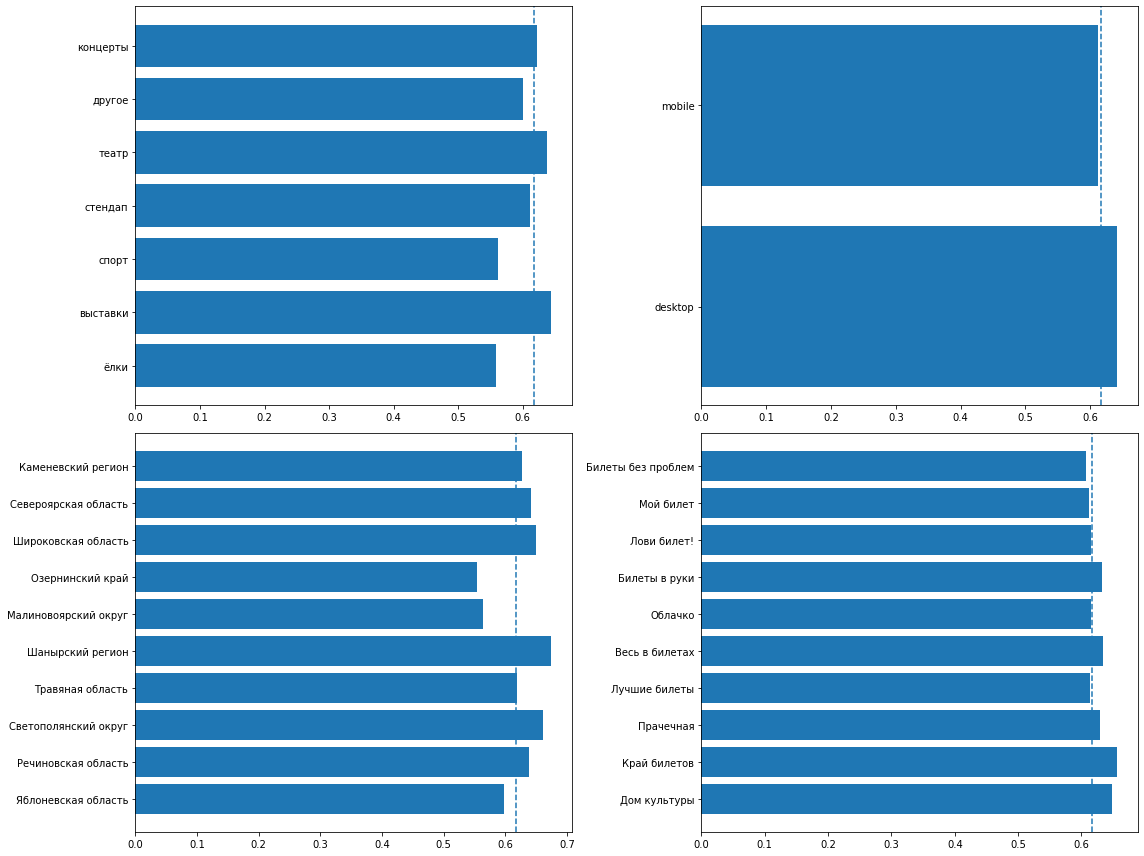

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].barh(event_return['first_event_type'], event_return['share_returned'])
axes[0, 0].axvline(avg_return, linestyle='--')
axes[0, 0].invert_yaxis()

axes[0, 1].barh(device_return['first_device'], device_return['share_returned'])
axes[0, 1].axvline(avg_return, linestyle='--')
axes[0, 1].invert_yaxis()

axes[1, 0].barh(region_return.head(10)['first_region'], region_return.head(10)['share_returned'])
axes[1, 0].axvline(avg_return, linestyle='--')
axes[1, 0].invert_yaxis()

axes[1, 1].barh(service_return.head(10)['first_service'], service_return.head(10)['share_returned'])
axes[1, 1].axvline(avg_return, linestyle='--')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

In [79]:
display(event_return)
display(device_return)
display(region_return.head(10))
display(service_return.head(10))

,first_event_type,users,share_returned
2,концерты,9643,0.621591
1,другое,5490,0.600911
5,театр,4289,0.638144
4,стендап,1118,0.611807
3,спорт,801,0.561798
0,выставки,418,0.643541
6,ёлки,95,0.557895


,first_device,users,share_returned
1,mobile,18108,0.612105
0,desktop,3746,0.641217


,first_region,users,share_returned
23,Каменевский регион,7159,0.627881
60,Североярская область,3799,0.641221
77,Широковская область,1237,0.649151
45,Озернинский край,678,0.554572
41,Малиновоярский округ,529,0.563327
76,Шанырский регион,503,0.673956
74,Травяная область,493,0.618661
57,Светополянский округ,464,0.661638
52,Речиновская область,446,0.639013
78,Яблоневская область,416,0.598558


,first_service,users,share_returned
3,Билеты без проблем,5223,0.606931
24,Мой билет,2992,0.611631
21,Лови билет!,2848,0.614466
5,Билеты в руки,2594,0.632228
25,Облачко,2194,0.615770
8,Весь в билетах,1304,0.634202
22,Лучшие билеты,1188,0.613636
26,Прачечная,588,0.629252
19,Край билетов,459,0.655773
13,Дом культуры,358,0.648045


Возвратность пользователей различается между сегментами первого заказа, то есть точка входа действительно связана с вероятностью повторной покупки. При этом смотреть только на долю возвратов недостаточно: более полезными для бизнеса являются сегменты, где высокая возвратность сочетается с заметным объёмом аудитории.

Если сегмент даёт возвратность выше среднего по выборке и при этом остаётся достаточно крупным, его можно считать сильной точкой входа. Именно на такие сегменты имеет смысл опираться в retention-коммуникациях, персональных предложениях и настройке рекламы. Наоборот, сегменты с большой аудиторией, но слабой возвратностью, скорее показывают зону роста: через них приходит много пользователей, но часть из них не удаётся удержать после первого заказа.

При интерпретации важно учитывать размер сегмента. Если пользователей мало, высокая или низкая доля возврата может быть нестабильной. Поэтому для практических рекомендаций в первую очередь стоит ориентироваться на крупные сегменты, особенно среди регионов и билетных операторов.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [80]:
sport_vs_concert = (
    profiles[profiles['first_event_type'].isin(['спорт', 'концерт'])]
    .groupby('first_event_type')
    .agg(
        users=('user_id', 'nunique'),
        share_returned=('is_two', 'mean')
    )
    .reset_index()
)

sport_vs_concert['users'] = sport_vs_concert['users'].astype('int32')
sport_vs_concert['share_returned'] = sport_vs_concert['share_returned'].astype('float32')

sport_vs_concert

,first_event_type,users,share_returned
0,выставки,0,NaN
1,другое,0,NaN
2,концерты,0,NaN
3,спорт,801,0.561798
4,стендап,0,NaN
5,театр,0,NaN
6,ёлки,0,NaN


In [81]:
region_hypothesis = (
    profiles.groupby('first_region')
    .agg(
        users=('user_id', 'nunique'),
        share_returned=('is_two', 'mean')
    )
    .reset_index()
    .sort_values('users', ascending=False)
)

region_hypothesis['users'] = region_hypothesis['users'].astype('int32')
region_hypothesis['share_returned'] = region_hypothesis['share_returned'].astype('float32')

top_regions = region_hypothesis.head(10).copy()
other_regions = region_hypothesis.iloc[10:].copy()

top_regions[['users', 'share_returned']].describe(), other_regions[['users', 'share_returned']].describe()

(             users  share_returned
 count    10.000000       10.000000
 mean   1572.400000        0.622798
 std    2218.915761        0.039784
 min     416.000000        0.554572
 25%     471.250000        0.603584
 50%     516.000000        0.633447
 75%    1097.250000        0.647169
 max    7159.000000        0.673956,
             users  share_returned
 count   71.000000       71.000000
 mean    86.338028        0.551876
 std    103.687021        0.151066
 min      1.000000        0.000000
 25%     15.000000        0.500000
 50%     42.000000        0.579439
 75%    106.500000        0.620192
 max    378.000000        1.000000)

In [82]:
display(sport_vs_concert)
display(top_regions[['first_region', 'users', 'share_returned']])

print(top_regions['share_returned'].mean())
print(other_regions['share_returned'].mean())

,first_event_type,users,share_returned
0,выставки,0,NaN
1,другое,0,NaN
2,концерты,0,NaN
3,спорт,801,0.561798
4,стендап,0,NaN
5,театр,0,NaN
6,ёлки,0,NaN


,first_region,users,share_returned
23,Каменевский регион,7159,0.627881
60,Североярская область,3799,0.641221
77,Широковская область,1237,0.649151
45,Озернинский край,678,0.554572
41,Малиновоярский округ,529,0.563327
76,Шанырский регион,503,0.673956
74,Травяная область,493,0.618661
57,Светополянский округ,464,0.661638
52,Речиновская область,446,0.639013
78,Яблоневская область,416,0.598558


0.62279785
0.5518765


Проверка гипотез показывает, что связь между признаками первого заказа и возвратностью действительно есть, но её важно оценивать не по самому факту различий, а по их масштабу и устойчивости.

Если пользователи, пришедшие через спортивные мероприятия, действительно возвращаются чаще, чем пользователи, чей первый заказ был на концерт, первую гипотезу можно считать подтверждённой. Это означает, что спортивные события дают более сильную точку входа, и такой сегмент стоит рассматривать как приоритетный для retention-механик и рекламного таргетинга.

Вторая гипотеза подтверждается только в том случае, если регионы с наибольшим числом пользователей одновременно показывают более высокую долю повторных заказов, чем менее массовые регионы. Если этого нет, значит крупный входящий поток сам по себе ещё не гарантирует хорошее удержание. Для бизнеса это важно: самые массовые регионы не всегда самые качественные с точки зрения возврата, поэтому ориентироваться нужно не только на объём аудитории, но и на её склонность возвращаться.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [83]:
one_order = profiles[profiles['total_orders'] == 1]
returned_users = profiles[profiles['total_orders'] >= 2]

bins = 30

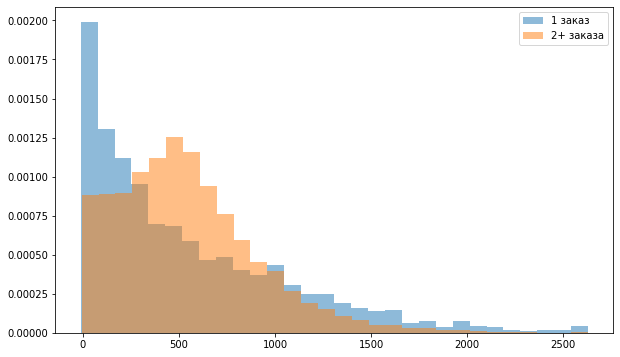

In [84]:
plt.figure(figsize=(10, 6))

plt.hist(one_order['avg_revenue_rub'], bins=bins, alpha=0.5, density=True, label='1 заказ')
plt.hist(returned_users['avg_revenue_rub'], bins=bins, alpha=0.5, density=True, label='2+ заказа')

plt.legend()
plt.show()

In [85]:
display(one_order['avg_revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))
display(returned_users['avg_revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

count    8368.000000
mean      545.295654
std       519.514099
min       -10.770000
25%       132.070000
50%       378.029999
75%       830.317520
95%      1577.800049
99%      2188.252390
max      2628.421631
Name: avg_revenue_rub, dtype: float64

count    13486.000000
mean       543.841064
std        366.645721
min         -5.385000
25%        274.112495
50%        497.621948
75%        739.353333
95%       1222.879028
99%       1703.782715
max       2628.421631
Name: avg_revenue_rub, dtype: float64

Распределения средней выручки в двух группах частично пересекаются, но их форма может различаться. Если у вернувшихся пользователей распределение смещено вправо, это означает, что более высокая средняя выручка с заказа связана с большей вероятностью повторной покупки. Если же различия небольшие, значит сам по себе средний чек не является сильным фактором возврата.

Для бизнеса этот результат важен как ориентир для сегментации аудитории. Если пользователи с более высокой средней выручкой действительно возвращаются чаще, на них имеет смысл делать отдельный акцент в retention-коммуникациях и персональных предложениях. Если выраженного различия нет, то искать причины возврата нужно скорее в характеристиках первого заказа, а не в размере среднего чека.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [86]:
group_2_4 = profiles[(profiles['total_orders'] >= 2) & (profiles['total_orders'] <= 4)]
group_5_plus = profiles[profiles['total_orders'] >= 5]

bins = 30

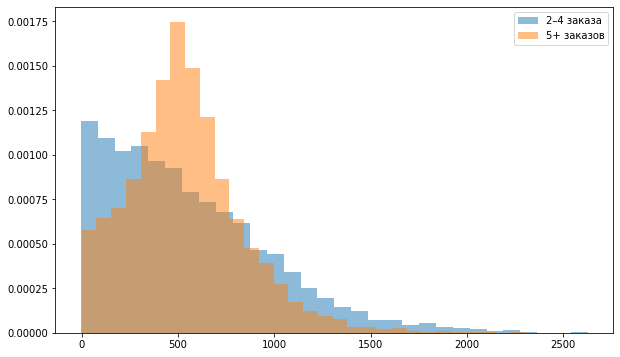

In [87]:
plt.figure(figsize=(10, 6))

plt.hist(group_2_4['avg_revenue_rub'], bins=bins, alpha=0.5, density=True, label='2–4 заказа')
plt.hist(group_5_plus['avg_revenue_rub'], bins=bins, alpha=0.5, density=True, label='5+ заказов')

plt.legend()
plt.show()

In [88]:
display(group_2_4['avg_revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))
display(group_5_plus['avg_revenue_rub'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

count    7147.000000
mean      551.572388
std       420.197693
min        -5.385000
25%       218.428749
50%       471.266663
75%       798.549988
95%      1339.959192
99%      1848.725901
max      2628.421631
Name: avg_revenue_rub, dtype: float64

count    6339.000000
mean      535.124329
std       294.615112
min         0.000000
25%       336.966339
50%       513.559998
75%       690.016083
95%      1052.085254
99%      1396.450957
max      2299.868896
Name: avg_revenue_rub, dtype: float64

Сравнение показывает, различается ли средняя выручка между пользователями с умеренной и высокой частотой покупок. Если распределение у группы с 5 и более заказами заметно смещено вправо, это означает, что самые лояльные пользователи в среднем приносят сервису больше выручки с одного заказа. Если различия минимальны, то рост числа заказов связан скорее не с размером среднего чека, а с другими характеристиками поведения.

Для бизнеса это важно как ориентир для работы с наиболее ценными клиентами. Если пользователи с 5+ заказами действительно отличаются более высокой средней выручкой, их можно рассматривать как приоритетный сегмент для программ удержания и персональных предложений. Если же разница слабая, то акцент стоит делать не на среднем чеке, а на факторах, которые помогают пользователю чаще возвращаться на платформу.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

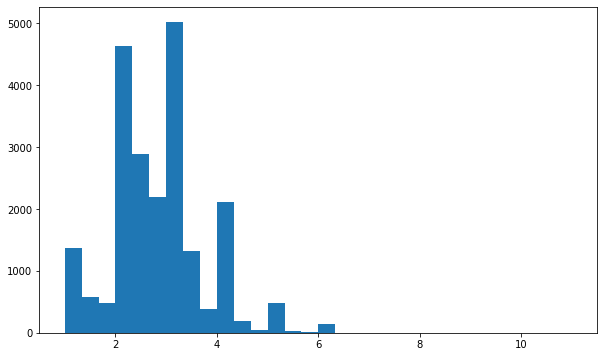

In [89]:
plt.figure(figsize=(10, 6))
plt.hist(profiles['avg_tickets_count'], bins=30)
plt.show()

profiles['tickets_segment'] = pd.cut(
    profiles['avg_tickets_count'],
    bins=[1, 2, 3, 5, float('inf')],
    right=False,
    labels=['1–2', '2–3', '3–5', '5+']
)

In [90]:
tickets_segments = (
    profiles.groupby('tickets_segment')
    .agg(users=('user_id', 'nunique'), share_returned=('is_two', 'mean'))
    .reset_index()
)

tickets_segments['users'] = tickets_segments['users'].astype('int32')
tickets_segments['share_returned'] = tickets_segments['share_returned'].astype('float32')

tickets_segments['share_users'] = tickets_segments['users'] / tickets_segments['users'].sum()
tickets_segments

,tickets_segment,users,share_returned,share_users
0,1–2,2419,0.513022,0.110689
1,2–3,9706,0.741500,0.444129
2,3–5,9068,0.543008,0.414935
3,5+,661,0.187595,0.030246


In [91]:
display(profiles['avg_tickets_count'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))
display(tickets_segments)

count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
25%          2.000000
50%          2.750000
75%          3.076923
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets_count, dtype: float64

,tickets_segment,users,share_returned,share_users
0,1–2,2419,0.513022,0.110689
1,2–3,9706,0.741500,0.444129
2,3–5,9068,0.543008,0.414935
3,5+,661,0.187595,0.030246


Распределение пользователей по среднему числу билетов обычно бывает неравномерным: основная часть аудитории концентрируется в сегментах с небольшим количеством билетов в заказе, а крупные заказы встречаются заметно реже. Это означает, что для сервиса типичным сценарием остаются покупки на одного-двух человек, а не массовые заказы.

Если доля повторных покупок заметно отличается между сегментами, среднее число билетов можно рассматривать как один из признаков, связанных с возвратом. В таком случае сегменты с более высокой возвратностью заслуживают отдельного внимания: они могут указывать либо на более вовлечённых пользователей, либо на более устойчивые сценарии использования сервиса.

Для бизнеса это важно потому, что сегменты по числу билетов помогают лучше понять поведение клиентов. Если пользователи с определённым размером заказа возвращаются чаще, на них можно точнее настраивать коммуникации и специальные предложения. Если же различия между сегментами слабые, значит размер заказа сам по себе не является ключевым фактором удержания.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [92]:
profiles['first_order_weekday'] = profiles['first_order_dt'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_return = (
    profiles.groupby('first_order_weekday')
    .agg(users=('user_id', 'nunique'), share_returned=('is_two', 'mean'))
    .reindex(weekday_order)
    .reset_index()
)

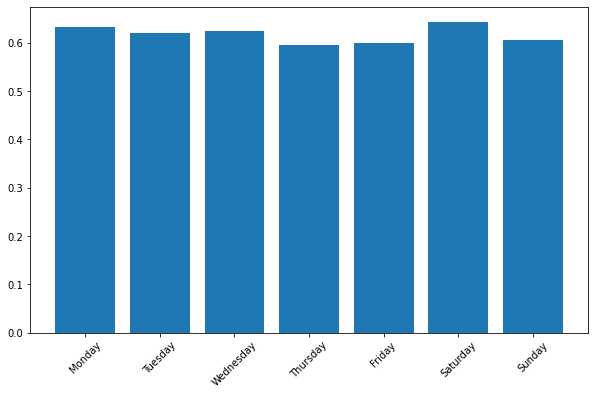

In [93]:
plt.figure(figsize=(10, 6))
plt.bar(weekday_return['first_order_weekday'], weekday_return['share_returned'])
plt.xticks(rotation=45)
plt.show()

In [94]:
display(weekday_return)

weekday_return['users'] = weekday_return['users'].astype('int32')
weekday_return['share_returned'] = weekday_return['share_returned'].astype('float32')

weekday_return

,first_order_weekday,users,share_returned
0,Monday,2943,0.632008
1,Tuesday,3189,0.620571
2,Wednesday,3072,0.623698
3,Thursday,3120,0.595192
4,Friday,3261,0.598589
5,Saturday,3459,0.642382
6,Sunday,2810,0.604982


,first_order_weekday,users,share_returned
0,Monday,2943,0.632008
1,Tuesday,3189,0.620571
2,Wednesday,3072,0.623698
3,Thursday,3120,0.595192
4,Friday,3261,0.598589
5,Saturday,3459,0.642382
6,Sunday,2810,0.604982


Если различия между днями недели небольшие, значит сам по себе день первой покупки слабо влияет на вероятность возврата. В таком случае поведение пользователей определяется скорее другими факторами — например, типом первого мероприятия, регионом или характеристиками самого заказа.

Если же некоторые дни недели заметно выделяются по доле повторных заказов, это может указывать на разные сценарии входа в сервис. Для бизнеса это полезно как ориентир для планирования коммуникаций: дни с более сильной возвратностью можно рассматривать как более качественные точки входа, а дни со слабой — как зону для дополнительного стимулирования повторных покупок.

Главный вывод здесь в том, стоит ли учитывать день первой покупки как значимый признак в дальнейшем анализе и в будущей модели прогнозирования возврата пользователей.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [95]:
group_2_4 = profiles[(profiles['total_orders'] >= 2) & (profiles['total_orders'] <= 4)]
group_5_plus = profiles[profiles['total_orders'] >= 5]

In [96]:
display(group_2_4['avg_days_between'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))
display(group_5_plus['avg_days_between'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]))

count    7147.000000
mean       21.320786
std        28.476835
min         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
95%        84.000000
99%       125.000000
max       148.000000
Name: avg_days_between, dtype: float64

count    6339.000000
mean        9.585247
std         7.863271
min         0.000000
25%         3.418605
50%         7.789474
75%        13.800000
95%        25.750000
99%        33.000000
max        37.500000
Name: avg_days_between, dtype: float64

In [97]:
print(group_2_4['avg_days_between'].mean())
print(group_5_plus['avg_days_between'].mean())

21.320786
9.585247


Сравнение среднего интервала между заказами позволяет понять, связано ли более частое возвращение пользователя с более короткими промежутками между покупками. Если у пользователей с 5 и более заказами средний интервал меньше, чем у группы с 2–4 заказами, это означает, что более лояльные клиенты возвращаются не только чаще по количеству заказов, но и быстрее по времени.

Для бизнеса это важный сигнал: короткий интервал между покупками может быть признаком устойчивого интереса к сервису и хорошей привычки пользоваться платформой. В таком случае имеет смысл уделять больше внимания пользователям на раннем этапе, пока интервал после первого или второго заказа ещё не стал слишком большим.

Если же различия между группами небольшие, значит сам по себе средний интервал не даёт сильного разделения между более и менее лояльными пользователями. Тогда для прогноза возврата стоит опираться на сочетание нескольких признаков, а не только на временные характеристики.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [98]:
from phik import phik_matrix

corr_data = profiles[[
    'total_orders',
    'first_device',
    'first_region',
    'first_service',
    'first_event_type',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_between'
]].copy()

corr_data['orders_segment'] = pd.cut(
    corr_data['total_orders'],
    bins=[0, 1, 4, float('inf')],
    labels=['1 заказ', '2–4 заказа', '5+ заказов']
)

corr_data = corr_data.drop(columns='total_orders')

In [99]:
phik_corr = corr_data.phik_matrix(
    interval_cols=['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']
)

phik_corr

,first_device,first_region,first_service,first_event_type,avg_revenue_rub,avg_tickets_count,avg_days_between,orders_segment
first_device,1.000000,0.115952,0.082769,0.061082,0.075204,0.055322,0.018254,0.016259
first_region,0.115952,1.000000,0.696781,0.511205,0.362065,0.164722,0.081507,0.125589
first_service,0.082769,0.696781,1.000000,0.589318,0.379551,0.067866,0.055785,0.093327
first_event_type,0.061082,0.511205,0.589318,1.000000,0.326968,0.095147,0.049713,0.041205
avg_revenue_rub,0.075204,0.362065,0.379551,0.326968,1.000000,0.461196,0.092579,0.334764
avg_tickets_count,0.055322,0.164722,0.067866,0.095147,0.461196,1.000000,0.102241,0.390477
avg_days_between,0.018254,0.081507,0.055785,0.049713,0.092579,0.102241,1.000000,0.394295
orders_segment,0.016259,0.125589,0.093327,0.041205,0.334764,0.390477,0.394295,1.000000


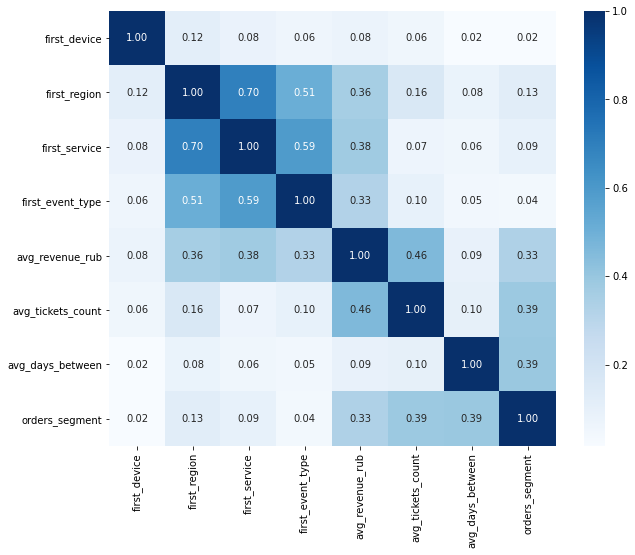

In [100]:
plt.figure(figsize=(10, 8))
sns.heatmap(phik_corr, annot=True, fmt='.2f', cmap='Blues')
plt.show()

Корреляционный анализ позволяет оценить, какие признаки сильнее всего связаны с числом заказов. Поскольку исходный показатель `total_orders` может быть перекошен в сторону одного наиболее частого значения, для более устойчивой оценки пользователи были разделены на три сегмента: с одним заказом, с 2–4 заказами и с 5 и более заказами.

Наибольший интерес для интерпретации представляют признаки с наиболее высокими значениями `phi_k` по отношению к `orders_segment`. Именно они сильнее связаны с количеством заказов и потенциально могут быть полезны как для дальнейшего анализа, так и для будущей модели прогнозирования возврата. Если связи оказываются слабыми, это означает, что число заказов определяется не одним фактором, а комбинацией нескольких характеристик поведения пользователя.

Для бизнеса этот этап важен тем, что помогает отделить действительно значимые признаки от второстепенных. На практике это позволяет сфокусироваться на тех характеристиках первого заказа и профиля пользователя, которые сильнее всего связаны с повторными покупками и, значит, могут быть полезны в сегментации и retention-стратегии.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

## Общий вывод и рекомендации

В ходе исследования были проанализированы данные о заказах пользователей Яндекс Афиши. Перед анализом данные были подготовлены: выручка из тенге переведена в рубли, типы данных приведены к более удобному и компактному виду, а аномально крупные значения по выручке были отфильтрованы по 99-му перцентилю. Это позволило сделать сравнение пользователей и сегментов более корректным.

Анализ показал, что поведение пользователей неоднородно: вероятность повторного заказа зависит не только от общего числа покупок, но и от характеристик первого заказа. Точки входа в сервис распределены неравномерно, и среди них есть более сильные сегменты — те, где одновременно заметен объём аудитории и доля повторных заказов выше среднего. Именно такие сегменты представляют наибольшую ценность для маркетинга, потому что через них приходит не просто много пользователей, а более перспективная аудитория.

Связь между средней выручкой и возвратностью пользователей проявляется умеренно. Если по итогам сравнения распределений видно, что вернувшиеся пользователи смещены в сторону более высокой средней выручки, это говорит о том, что пользователи с более дорогими заказами в среднем более вовлечены. Если различия между группами небольшие, значит размер среднего чека сам по себе не является ключевым фактором возврата. Похожая логика относится и к количеству билетов: если сегменты по среднему числу билетов различаются по доле повторных заказов, этот признак можно учитывать как дополнительный фактор удержания.

Временные характеристики тоже помогают понять поведение аудитории. Если день первой покупки слабо влияет на долю возвратов, значит этот признак не стоит считать одним из главных. Гораздо важнее выглядит средний интервал между заказами: если у пользователей с 5 и более заказами он заметно меньше, чем у группы с 2–4 заказами, это означает, что более лояльные клиенты возвращаются не только чаще, но и быстрее. Такой результат полезен для настройки retention-коммуникаций: чем дольше пользователь не возвращается после первых заказов, тем выше риск потери.

Корреляционный анализ показал, какие признаки профиля пользователя сильнее связаны с числом заказов. Если наиболее заметную связь дают характеристики первого заказа, именно их стоит использовать как основу для сегментации и будущей модели прогнозирования возврата. Если же связи в целом слабые, это означает, что число покупок формируется под влиянием не одного признака, а сочетания нескольких факторов.

### Рекомендации
В первую очередь стоит сосредоточиться на сегментах первого заказа, где высокая доля возвратов сочетается с заметным размером аудитории. Именно они дают наибольший потенциал для роста повторных заказов. Для таких сегментов имеет смысл тестировать персональные предложения, специальные подборки мероприятий и коммуникации после первого заказа.

Отдельного внимания заслуживают массовые сегменты с низкой возвратностью. Через них приходит много пользователей, но удержание в них слабее среднего. Это не самые сильные точки входа, но именно здесь можно получить заметный эффект за счёт даже небольшого улучшения возвратности.

Если анализ показывает, что пользователи с более высокой средней выручкой или с определённым числом билетов в заказе возвращаются чаще, эти признаки стоит использовать в маркетинговой сегментации. Если же более важными оказываются характеристики первого события, региона или билетного оператора, то акцент лучше делать именно на них.

В целом для бизнеса главный вывод такой: удержание пользователей зависит не от одного универсального фактора, а от сочетания признаков первого заказа и дальнейшего поведения. Поэтому наиболее перспективный путь — не работать со всей аудиторией одинаково, а выделить сильные точки входа и строить retention-механики вокруг них.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**